In [1]:
!pip install -q kagglehub[pandas-datasets]
import kagglehub
import pandas as pd
import os

# Download TextOCR dataset
print("Downloading TextOCR dataset...")
textocr_path = kagglehub.dataset_download("robikscube/textocr-text-extraction-from-images-dataset")
print("TextOCR Path:", textocr_path)

# List files to be sure of the names
print("\nFiles in dataset:", os.listdir(textocr_path))

# Try to read and display annot.csv
annot_csv_path = os.path.join(textocr_path, "annot.csv")
if os.path.exists(annot_csv_path):
    print("\n--- annot.csv ---")
    annot_df = pd.read_csv(annot_csv_path, nrows=5)
    display(annot_df)
else:
    print(f"{annot_csv_path} not found.")

# Try to read and display image.csv (or similarly named file)
for file in os.listdir(textocr_path):
    if 'img' in file.lower() and file.endswith('.csv'):
        img_csv_path = os.path.join(textocr_path, file)
        print(f"\n--- {file} ---")
        img_df = pd.read_csv(img_csv_path, nrows=5)
        display(img_df)
        break


Resuming download from 2822766592 bytes (4401417564 bytes left)...
Resuming download to /root/.cache/kagglehub/datasets/robikscube/textocr-text-extraction-from-images-dataset/2.archive (2822766592/7224184156) bytes left.


100%|██████████| 6.73G/6.73G [00:24<00:00, 179MB/s]

Extracting files...


TextOCR Path: /root/.cache/kagglehub/datasets/robikscube/textocr-text-extraction-from-images-dataset/versions/2

Files in dataset: ['annot.csv', 'img.csv', 'TextOCR_0.1_train.json', 'annot.parquet', 'train_val_images', 'img.parquet']

--- annot.csv ---


,Unnamed: 0,id,image_id,bbox,utf8_string,points,area
0,0,a4ea732cd3d5948a_1,a4ea732cd3d5948a,"[525.83, 3.4, 197.64, 33.94]",Performance,"[525.83, 3.4, 723.47, 7.29, 722.76, 36.99, 525...",6707.90
1,1,a4ea732cd3d5948a_2,a4ea732cd3d5948a,"[534.67, 64.68, 91.22, 38.19]",Sport,"[535.73, 64.68, 623.41, 67.51, 625.89, 102.87,...",3483.69
2,2,a4ea732cd3d5948a_3,a4ea732cd3d5948a,"[626.95, 63.62, 96.52, 31.82]",Watch,"[626.95, 63.62, 721.7, 63.62, 723.47, 95.44, 6...",3071.27
3,3,a4ea732cd3d5948a_4,a4ea732cd3d5948a,"[577.4, 141.87, 147.13, 43.1]",...period.,"[580.02, 143.61, 724.53, 141.87, 723.66, 184.9...",6341.30
4,4,a4ea732cd3d5948a_5,a4ea732cd3d5948a,"[391.03, 163.9, 60.82, 38.65]",.,"[395.2, 163.9, 451.85, 191.94, 445.59, 202.55,...",2350.69



--- img.csv ---


,Unnamed: 0,id,width,height,set,file_name
0,0,a4ea732cd3d5948a,840,1024,train,train/a4ea732cd3d5948a.jpg
1,1,4bf43a7b2a898044,1024,683,train,train/4bf43a7b2a898044.jpg
2,2,1b55b309b0f50d02,1024,683,train,train/1b55b309b0f50d02.jpg
3,3,00c359f294f7dcd9,1024,680,train,train/00c359f294f7dcd9.jpg
4,4,04b5a37f762b0f51,768,1024,train,train/04b5a37f762b0f51.jpg


In [2]:
import ast
import re
import random
from sklearn.model_selection import train_test_split

# 1. Load TextOCR DataFrames
print("Loading TextOCR annotations...")
annot_df = pd.read_csv(annot_csv_path)
img_df = pd.read_csv(img_csv_path)

# Merge to get file paths alongside annotations
merged_df = annot_df.merge(img_df, left_on='image_id', right_on='id', suffixes=('_annot', '_img'))

# Drop NaNs or empty strings
merged_df = merged_df.dropna(subset=['utf8_string', 'bbox', 'file_name'])
merged_df = merged_df[merged_df['utf8_string'].str.strip() != '']

textocr_img_dir = os.path.join(textocr_path, "train_val_images", "train_images")

# 2. Sample 2110 unique images, then collect all crops from those images
SEED = 42
random.seed(SEED)
unique_img_names = merged_df['file_name'].apply(lambda x: x.split('/')[-1]).unique()
textocr_img_sample = random.sample(list(unique_img_names), 3010)

# Filter merged_df for these images
textocr_img_df = merged_df[merged_df['file_name'].apply(lambda x: x.split('/')[-1]).isin(textocr_img_sample)]

# Group by image for splitting
img_to_records = {}
for img_name in textocr_img_sample:
    img_records = textocr_img_df[textocr_img_df['file_name'].apply(lambda x: x.split('/')[-1]) == img_name]
    img_to_records[img_name] = img_records

# Split images into train/val/test (2110 train, 300 val, 600 test images)
train_imgs, temp_imgs = train_test_split(textocr_img_sample, train_size=2110, random_state=SEED)
val_imgs, test_imgs = train_test_split(temp_imgs, train_size=300, random_state=SEED)

# Helper to get all crops for a list of images
def get_crops_for_imgs(img_list):
    crops = []

    for img_name in img_list:
        img_records = img_to_records[img_name]

        for _, row in img_records.iterrows():
            # extract text FIRST
            text = str(row['utf8_string']).strip()

            # basic filter
            if text == '###' or len(text) == 0:
                continue

            # normalize
            text = text.lower()
            text = re.sub(r'[^a-z0-9]', '', text)

            # filtering
            if len(text) < 2:
                continue
            if len(text) > 25:
                continue

            try:
                bbox = ast.literal_eval(row['bbox'])
                x, y, w, h = bbox
                polygon = [(x, y), (x+w, y), (x+w, y+h), (x, y+h)]

                img_file_path = os.path.join(textocr_img_dir, img_name)

                crops.append((img_file_path, text, polygon))

            except:
                continue

    return crops

textocr_train = get_crops_for_imgs(train_imgs)
textocr_val = get_crops_for_imgs(val_imgs)
textocr_test = get_crops_for_imgs(test_imgs)

print("\n--- TextOCR Dataset Splits (by images) ---")
print(f"Train: {len(textocr_train)} crops from {len(train_imgs)} images")
print(f"Val:   {len(textocr_val)} crops from {len(val_imgs)} images")
print(f"Test:  {len(textocr_test)} crops from {len(test_imgs)} images")

# Optionally, save the split for reproducibility
import pickle
with open('textocr_split.pkl', 'wb') as f:
    pickle.dump({'train': textocr_train, 'val': textocr_val, 'test': textocr_test}, f)


Loading TextOCR annotations...

--- TextOCR Dataset Splits (by images) ---
Train: 57584 crops from 2110 images
Val:   7487 crops from 300 images
Test:  18527 crops from 600 images


In [3]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q opencv-python-headless matplotlib Pillow scipy scikit-learn editdistance
!pip install -q gdown

import torch
print(f'PyTorch: {torch.__version__}')
print(f'GPU available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch: 2.10.0+cu128
GPU available: True
GPU: Tesla T4


In [4]:
import os
import gdown
import shutil
import zipfile
import kagglehub

# Download dataset
path = kagglehub.dataset_download("ipythonx/totaltextstr")

print("Path to dataset files:", path)

# Target directory
TARGET_DIR = '/content/data/totaltext'

# Find actual dataset folder (sometimes nested)
def find_total_text_dir(root):
    for dirpath, dirnames, filenames in os.walk(root):
        if 'Train' in dirnames and 'Test' in dirnames and 'Annotation' in dirnames:
            return dirpath
    return None

SOURCE_DIR = find_total_text_dir(path)

if SOURCE_DIR is None:
    raise Exception("Could not find dataset structure!")

print("Using dataset at:", SOURCE_DIR)

# Create clean structure
train_dst = os.path.join(TARGET_DIR, 'images/train')
test_dst = os.path.join(TARGET_DIR, 'images/test')
annot_dst = os.path.join(TARGET_DIR, 'annotations')

os.makedirs(train_dst, exist_ok=True)
os.makedirs(test_dst, exist_ok=True)

# Copy data
shutil.copytree(os.path.join(SOURCE_DIR, 'Train'), train_dst, dirs_exist_ok=True)
shutil.copytree(os.path.join(SOURCE_DIR, 'Test'), test_dst, dirs_exist_ok=True)
shutil.copytree(os.path.join(SOURCE_DIR, 'Annotation'), annot_dst, dirs_exist_ok=True)

print("Dataset ready at:", TARGET_DIR)

100%|██████████| 494M/494M [00:03<00:00, 150MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ipythonx/totaltextstr/versions/1
Using dataset at: /root/.cache/kagglehub/datasets/ipythonx/totaltextstr/versions/1/Total-Text
Dataset ready at: /content/data/totaltext


In [5]:

# Verify structure
!find data/totaltext -maxdepth 3 -type d | head -20

data/totaltext
data/totaltext/annotations
data/totaltext/annotations/groundtruth_pixel
data/totaltext/annotations/groundtruth_pixel/Train
data/totaltext/annotations/groundtruth_pixel/Test
data/totaltext/annotations/groundtruth_polygonal_annotation
data/totaltext/annotations/groundtruth_polygonal_annotation/Train
data/totaltext/annotations/groundtruth_polygonal_annotation/Test
data/totaltext/annotations/groundtruth_textregion
data/totaltext/annotations/groundtruth_textregion/Train
data/totaltext/annotations/groundtruth_textregion/Test
data/totaltext/images
data/totaltext/images/test
data/totaltext/images/train


In [44]:
import os
import re
import glob
import json
import random
import numpy as np
import cv2
import editdistance
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec

# ─── CONFIG ────────────────────────────────────────────────────────────────
class Config:
    # Paths
    TRAIN_IMG_DIR  = 'data/totaltext/images/train'
    TEST_IMG_DIR   = 'data/totaltext/images/test'
    TRAIN_GT_DIR   = 'data/totaltext/annotations/groundtruth_polygonal_annotation/Train'
    TEST_GT_DIR    = 'data/totaltext/annotations/groundtruth_polygonal_annotation/Test'

    # Image
    IMG_HEIGHT     = 32      # Fixed height for CRNN input
    IMG_WIDTH      = 160     # Fixed width (or use variable with padding)
    IMG_CHANNELS   = 1       # Grayscale

    # Model
    CNN_OUT_CHANNELS   = 512
    RNN_HIDDEN_SIZE    = 256
    RNN_NUM_LAYERS     = 2
    RNN_DROPOUT        = 0.1
    LEAKY_RELU         = False

    # Training
    BATCH_SIZE     = 64
    # NUM_EPOCHS     = 3
    NUM_EPOCHS     = 30
    LR             = 1e-4
    LR_STEP        = 10
    LR_GAMMA       = 0.5
    WEIGHT_DECAY   = 1e-5
    GRAD_CLIP      = 5.0
    NUM_WORKERS    = 2
    SEED           = 42

    # Charset
    CHARSET        = '0123456789abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ!\"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~ '
    BLANK_IDX      = 0       # CTC blank token index

    DEVICE         = 'cuda' if torch.cuda.is_available() else 'cpu'
    SAVE_PATH      = 'crnn_totaltext_best.pth'
    # PRETRAINED_PATH = 'crnn_pretrained_synthtext.pth'

cfg = Config()

# Reproducibility
random.seed(cfg.SEED)
np.random.seed(cfg.SEED)
torch.manual_seed(cfg.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.SEED)

print(f'Device: {cfg.DEVICE}')
print(f'Charset size: {len(cfg.CHARSET)}')

Device: cuda
Charset size: 95


In [7]:
class LabelEncoder:
    """Maps characters <-> integer indices. Index 0 is reserved for CTC blank."""

    def __init__(self, charset: str):
        # index 0 = blank (CTC)
        self.chars = ['[BLANK]'] + list(charset)
        self.char2idx = {c: i for i, c in enumerate(self.chars)}
        self.idx2char = {i: c for i, c in enumerate(self.chars)}
        self.num_classes = len(self.chars)  # includes blank

    def encode(self, text: str):
        """str → LongTensor of indices (unknown chars replaced with space)."""
        indices = []
        for ch in text:
            idx = self.char2idx.get(ch, self.char2idx.get(' ', 1))
            indices.append(idx)
        return torch.LongTensor(indices)

    def decode(self, indices, remove_duplicates=True, remove_blank=True):
        """LongTensor/list → str (CTC greedy decode)."""
        result = []
        prev = None
        for idx in indices:
            idx = int(idx)
            if remove_duplicates and idx == prev:
                prev = idx
                continue
            prev = idx
            if remove_blank and idx == 0:
                continue
            char = self.idx2char.get(idx, '')
            if char != '[BLANK]':
                result.append(char)
        return ''.join(result)

label_encoder = LabelEncoder(cfg.CHARSET)
print(f'Num classes (incl. blank): {label_encoder.num_classes}')

# Quick test
sample = 'Hello123'
enc = label_encoder.encode(sample)
dec = label_encoder.decode(enc)
print(f'Encode→Decode test: "{sample}" → {enc.tolist()} → "{dec}"')

Num classes (incl. blank): 96
Encode→Decode test: "Hello123" → [44, 15, 22, 22, 25, 2, 3, 4] → "Helo123"


In [8]:
def parse_totaltext_annotations(img_dir, gt_dir):
    records = []

    img_paths = glob.glob(os.path.join(img_dir, '*.jpg'))
    print(f'Found {len(img_paths)} images in {img_dir}')

    for img_path in img_paths:
        img_name = os.path.basename(img_path)
        gt_name = f'gt_{os.path.splitext(img_name)[0]}.txt'
        gt_path = os.path.join(gt_dir, gt_name)

        if not os.path.exists(gt_path):
            continue

        with open(gt_path, 'r', encoding='utf-8') as f:
            content = f.read()

        # Find all annotation entries
        matches = re.findall(
            r"x:\s*\[(.*?)\],\s*y:\s*\[(.*?)\],\s*transcription:\s*'([^']*)'",
            content
        )

        for x_str, y_str, text in matches:
            # Skip illegible text
            if text.strip() == '###':
                continue

            try:
                xs = list(map(int, re.split(r'[,\s]+', x_str.strip())))
                ys = list(map(int, re.split(r'[,\s]+', y_str.strip())))

                if len(xs) != len(ys) or len(xs) < 3:
                    continue

                polygon = list(zip(xs, ys))

                records.append((img_path, text, polygon))

            except:
                continue

    print(f'Total word crops: {len(records)}')
    return records


def crop_polygon_region(image: np.ndarray, polygon: list, target_h: int = 32):
    """
    Crops the bounding-box of a polygon from an image and resizes to target_h.
    Returns a grayscale image of shape (target_h, W).
    """
    pts = np.array(polygon, dtype=np.int32)
    x, y, w, h = cv2.boundingRect(pts)
    x, y = max(0, x), max(0, y)
    x2  = min(image.shape[1], x + w)
    y2  = min(image.shape[0], y + h)
    if x2 <= x or y2 <= y:
        return None
    crop = image[y:y2, x:x2]
    if crop.size == 0:
        return None
    # Convert to grayscale
    if len(crop.shape) == 3:
        crop = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    # Resize keeping aspect ratio, pad to fixed width
    aspect = w / max(h, 1)
    new_w  = max(1, int(target_h * aspect))
    crop   = cv2.resize(crop, (new_w, target_h))
    return crop


def parse_totaltext_gt(gt_file):
    anns = []

    with open(gt_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    for line in lines:
        try:
            # Extract x and y (inside double brackets)
            x_match = re.search(r"x:\s*\[\[([^\]]+)\]\]", line)
            y_match = re.search(r"y:\s*\[\[([^\]]+)\]\]", line)

            # Extract transcription
            t_match = re.search(r"transcriptions:\s*\[u'([^']*)'\]", line)

            if not x_match or not y_match or not t_match:
                continue

            text = t_match.group(1).strip()

            # Skip illegible
            if text == '#' or text == '###':
                continue

            xs = list(map(int, x_match.group(1).split()))
            ys = list(map(int, y_match.group(1).split()))

            if len(xs) != len(ys) or len(xs) < 3:
                continue

            polygon = list(zip(xs, ys))

            anns.append({
                'text': text,
                'polygon': polygon
            })

        except:
            continue

    return anns

def build_dataset_records(img_dir: str, gt_dir: str):
    """Walk through Total Text split and return list of (img_path, text, polygon)."""
    records = []
    img_paths = glob.glob(os.path.join(img_dir, '*.jpg')) + \
                glob.glob(os.path.join(img_dir, '*.png'))
    print(f'Found {len(img_paths)} images in {img_dir}')
    for img_path in img_paths:
        stem = Path(img_path).stem  # e.g. 'img1001'
        gt_file = os.path.join(gt_dir, f'poly_gt_{stem}.txt')
        if not os.path.exists(gt_file):
            continue
        anns = parse_totaltext_gt(gt_file)
        for ann in anns:
            records.append((img_path, ann['text'], ann['polygon']))
    print(f'Total word crops: {len(records)}')
    return records


train_records = build_dataset_records(cfg.TRAIN_IMG_DIR, cfg.TRAIN_GT_DIR)
test_records  = build_dataset_records(cfg.TEST_IMG_DIR,  cfg.TEST_GT_DIR)
print(f'Train: {len(train_records)}, Test: {len(test_records)}')

Found 1254 images in data/totaltext/images/train
Total word crops: 9278
Found 300 images in data/totaltext/images/test
Total word crops: 2189
Train: 9278, Test: 2189


In [45]:
import os
import cv2
import numpy as np
from tqdm import tqdm
class TotalTextDataset(Dataset):
    def __init__(self, records, label_encoder, cfg, augment=False):
        self.records       = records
        self.label_encoder = label_encoder
        self.cfg           = cfg
        self.augment       = augment
        self.max_width     = cfg.IMG_WIDTH
        self.height        = cfg.IMG_HEIGHT

        aug_list = []
        if augment:
            aug_list += [
                transforms.RandomAffine(degrees=3, shear=5),
                transforms.ColorJitter(brightness=0.3, contrast=0.3),
                transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
            ]
        self.pil_transform = transforms.Compose(aug_list) if aug_list else None
        self.to_tensor     = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        img_path, text, _ = self.records[idx]

        # Load pre-cropped grayscale image directly
        crop = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if crop is None:
            img_t = torch.zeros(1, self.height, self.max_width)
            label = self.label_encoder.encode('a')
            return img_t, label, len(label)

        h, w = crop.shape
        if w > self.max_width:
            crop = crop[:, :self.max_width]
        elif w < self.max_width:
            pad = np.zeros((h, self.max_width - w), dtype=np.uint8)
            crop = np.concatenate([crop, pad], axis=1)

        pil_img = Image.fromarray(crop)
        if self.pil_transform:
            pil_img = self.pil_transform(pil_img)
        img_t = self.to_tensor(pil_img)
        label = self.label_encoder.encode(text)
        return img_t, label, len(label)

def collate_fn(batch):
    images, labels, lengths = zip(*batch)
    images  = torch.stack(images, 0)
    lengths = torch.LongTensor(lengths)
    targets = torch.cat(labels)
    return images, targets, lengths

import random
from sklearn.model_selection import train_test_split

# --- Merge TotalText and TextOCR ---
print("Merging datasets...")
# Use all of TotalText: 1105 train, 150 val, 300 test images
# Use all word crops from these images
# Use preselected TextOCR splits: 2110 train, 300 val, 600 test

tt_train_records = train_records  # all 1105 train images' crops
# For val/test, sample 150/300 images from test_records, use all their crops
random.seed(cfg.SEED)
tt_val_imgs = random.sample(test_records, 150)
tt_test_imgs = [img for img in test_records if img not in tt_val_imgs]
tt_test_imgs = random.sample(tt_test_imgs, 300)

def filter_records_by_imgs(records, img_list):
    img_set = set([r[0] for r in img_list])
    return [r for r in records if r[0] in img_set]

tt_val_records = filter_records_by_imgs(test_records, tt_val_imgs)
tt_test_records = filter_records_by_imgs(test_records, tt_test_imgs)

# Load TextOCR splits from file (for reproducibility)
import pickle
with open('textocr_split.pkl', 'rb') as f:
    textocr_split = pickle.load(f)
textocr_train = textocr_split['train']
textocr_val = textocr_split['val']
textocr_test = textocr_split['test']

final_train_records = tt_train_records + textocr_train
final_val_records = tt_val_records + textocr_val
final_test_records = tt_test_records + textocr_test

random.shuffle(final_train_records)
FAST_MODE = True
FAST_FRAC = 0.25

if FAST_MODE:
    random.seed(cfg.SEED)
    final_train_records = random.sample(final_train_records, int(len(final_train_records) * FAST_FRAC))
    final_val_records   = random.sample(final_val_records,   int(len(final_val_records)   * FAST_FRAC))
    final_test_records  = random.sample(final_test_records,  int(len(final_test_records)  * FAST_FRAC))
    print(f"[FAST MODE] Train: {len(final_train_records)}, Val: {len(final_val_records)}")


def pre_crop_dataset(records, output_dir, target_h=32):
    """
    Crop all word regions once and save as individual images.
    Returns new records pointing to the pre-cropped files.
    """
    os.makedirs(output_dir, exist_ok=True)
    new_records = []

    for i, (img_path, text, polygon) in enumerate(tqdm(records, desc="Pre-cropping")):
        image = cv2.imread(img_path)
        if image is None:
            continue

        crop = crop_polygon_region(image, polygon, target_h=target_h)
        if crop.shape[1] < 8:
            continue
        if crop is None:
            continue

        crop_path = os.path.join(output_dir, f"{i:06d}.png")
        cv2.imwrite(crop_path, crop)
        new_records.append((crop_path, text, None))  # polygon no longer needed

    print(f"Saved {len(new_records)} crops to {output_dir}")
    return new_records

# Run once -- takes a few minutes but saves hours later
final_train_records = pre_crop_dataset(final_train_records, "data/crops/train", cfg.IMG_HEIGHT)
final_val_records   = pre_crop_dataset(final_val_records,   "data/crops/val",   cfg.IMG_HEIGHT)
final_test_records  = pre_crop_dataset(final_test_records,  "data/crops/test",  cfg.IMG_HEIGHT)
print(f"Final Train: {len(final_train_records)} crops")
print(f"Final Val:   {len(final_val_records)} crops")
print(f"Final Test:  {len(final_test_records)} crops")

# --- Create Datasets ---
train_ds = TotalTextDataset(final_train_records, label_encoder, cfg, augment=True)
val_ds   = TotalTextDataset(final_val_records,   label_encoder, cfg, augment=False)
test_ds  = TotalTextDataset(final_test_records,  label_encoder, cfg, augment=False)

train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                          num_workers=cfg.NUM_WORKERS, collate_fn=collate_fn,
                          pin_memory=True)
val_loader  = DataLoader(val_ds,  batch_size=cfg.BATCH_SIZE, shuffle=False,
                          num_workers=cfg.NUM_WORKERS, collate_fn=collate_fn,
                          pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=cfg.BATCH_SIZE, shuffle=False,
                          num_workers=cfg.NUM_WORKERS, collate_fn=collate_fn,
                          pin_memory=True)

print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}')


Merging datasets...
[FAST MODE] Train: 16715, Val: 2160


Pre-cropping: 100%|██████████| 16715/16715 [02:09<00:00, 129.03it/s]


Saved 16607 crops to data/crops/train


Pre-cropping: 100%|██████████| 2160/2160 [00:16<00:00, 129.99it/s]


Saved 2136 crops to data/crops/val


Pre-cropping: 100%|██████████| 5038/5038 [00:37<00:00, 133.66it/s]

Saved 5013 crops to data/crops/test
Final Train: 16607 crops
Final Val:   2136 crops
Final Test:  5013 crops
Train batches: 260, Val batches: 34, Test batches: 79


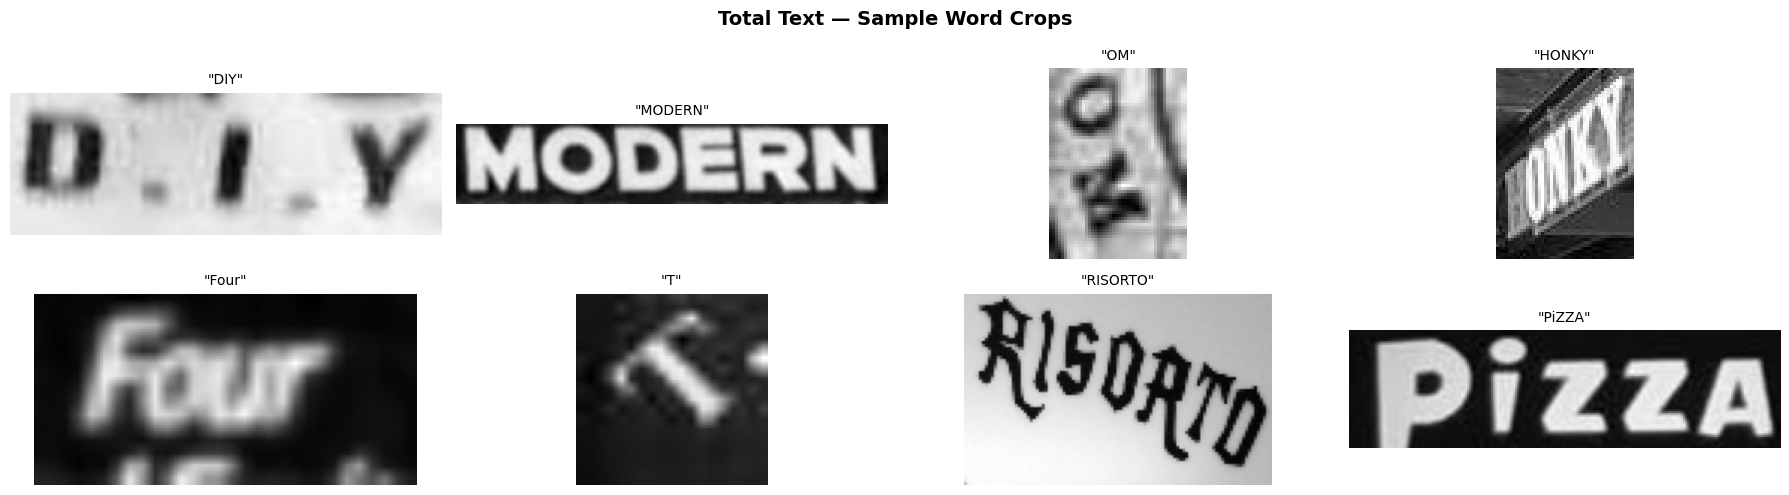

In [31]:
def show_samples(records, n=8):
    fig, axes = plt.subplots(2, n//2, figsize=(18, 5))
    axes = axes.flatten()
    sampled = random.sample(records, n)
    for i, (img_path, text, polygon) in enumerate(sampled):
        image = cv2.imread(img_path)
        if image is None:
            continue
        crop = crop_polygon_region(image, polygon, target_h=64)
        if crop is None:
            continue
        axes[i].imshow(crop, cmap='gray')
        axes[i].set_title(f'"{text}"', fontsize=10)
        axes[i].axis('off')
    plt.suptitle('Total Text — Sample Word Crops', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_samples(train_records)

In [32]:
"""
Architecture: CNN feature extractor -> Map-to-Sequence -> Bidirectional LSTM -> CTC
- CNN: 7-layer conv stack with BN, producing (batch, C, 1, W') feature maps
- RNN: 2-layer BiLSTM over the W' time steps
- CTC: connectionist temporal classification loss for alignment-free training

Designed to work with TotalText + TextOCR merged dataset pipeline.
"""

import time
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import editdistance
from collections import OrderedDict


# ---------------------------------------------------------------------------
# Model Components
# ---------------------------------------------------------------------------

class BidirectionalLSTM(nn.Module):
    """Single BiLSTM layer followed by a linear projection."""

    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, bidirectional=True, batch_first=True)
        self.linear = nn.Linear(hidden_size * 2, output_size)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        recurrent, _ = self.rnn(x)
        output = self.linear(recurrent)  # (batch, seq_len, output_size)
        return output


class CRNN(nn.Module):
    """
    Convolutional Recurrent Neural Network for scene text recognition.

    Input:  (batch, 1, 32, W)  -- grayscale images of fixed height 32
    Output: (seq_len, batch, num_classes)  -- log-probabilities per time step

    The CNN collapses the height dimension to 1 through pooling, producing a
    feature sequence of length W' ~ W/4. Each column becomes a time step for
    the RNN, which outputs per-frame class scores for CTC decoding.

    Args:
        num_classes:    size of output alphabet (including CTC blank at index 0)
        cnn_out_ch:     number of channels in the final conv layer
        rnn_hidden:     hidden size per direction in each BiLSTM layer
        rnn_layers:     number of stacked BiLSTM layers (minimum 2)
        rnn_dropout:    dropout between BiLSTM layers (only active if rnn_layers > 1)
        leaky_relu:     use LeakyReLU instead of ReLU in the CNN
    """

    def __init__(self, num_classes, cnn_out_ch=512, rnn_hidden=256,
                 rnn_layers=2, rnn_dropout=0.1, leaky_relu=False):
        super().__init__()
        self.num_classes = num_classes
        self.cnn = self._build_cnn(cnn_out_ch, leaky_relu)
        self.rnn = self._build_rnn(cnn_out_ch, rnn_hidden, rnn_layers,
                                   rnn_dropout, num_classes)

    # -- CNN backbone ----------------------------------------------------------

    @staticmethod
    def _build_cnn(out_ch, leaky_relu):
        """
        7-layer CNN that maps (B, 1, 32, W) -> (B, out_ch, 1, W').

        Layer config follows the classic CRNN paper (Shi et al., 2016):
          conv -> pool -> conv -> pool -> conv -> conv -> pool(h-only)
          -> conv -> BN -> conv -> BN -> pool(h-only) -> conv

        Height is reduced 32 -> 16 -> 8 -> 4 -> 2 -> 1 via pooling.
        Width is reduced only by the two (2,2) pools, so W' ~ W/4.
        """
        act = nn.LeakyReLU(0.2, inplace=True) if leaky_relu else nn.ReLU(inplace=True)

        # Channel progression: 1 -> 64 -> 128 -> 256 -> 256 -> 512 -> 512 -> 512
        layers = OrderedDict()

        def _add(name, *modules):
            for i, m in enumerate(modules):
                layers[f"{name}_{i}" if len(modules) > 1 else name] = m

        # Block 1: conv(64) + pool 2x2
        _add("conv0", nn.Conv2d(1, 64, 3, 1, 1), act)
        layers["pool0"] = nn.MaxPool2d(2, 2)  # 32->16, W->W/2

        # Block 2: conv(128) + pool 2x2
        _add("conv1", nn.Conv2d(64, 128, 3, 1, 1), act)
        layers["pool1"] = nn.MaxPool2d(2, 2)  # 16->8, W/2->W/4

        # Block 3: conv(256) + conv(256) + pool (2,1) height-only
        _add("conv2", nn.Conv2d(128, 256, 3, 1, 1), act)
        _add("conv3", nn.Conv2d(256, 256, 3, 1, 1), act)
        layers["pool2"] = nn.MaxPool2d((2, 1), (2, 1))  # 8->4

        # Block 4: conv(512)+BN + conv(512)+BN + pool (2,1) height-only
        _add("conv4", nn.Conv2d(256, 512, 3, 1, 1))
        layers["bn4"] = nn.BatchNorm2d(512)
        layers["act4"] = copy.deepcopy(act)

        _add("conv5", nn.Conv2d(512, 512, 3, 1, 1))
        layers["bn5"] = nn.BatchNorm2d(512)
        layers["act5"] = copy.deepcopy(act)

        layers["pool3"] = nn.MaxPool2d((2, 1), (2, 1))  # 4->2

        # Block 5: conv(512)+BN -- collapses remaining height (kernel h=2)
        _add("conv6", nn.Conv2d(512, out_ch, 2, 1, 0))  # 2->1
        layers["bn6"] = nn.BatchNorm2d(out_ch)
        layers["act6"] = copy.deepcopy(act)

        return nn.Sequential(layers)

    # -- RNN head --------------------------------------------------------------

    @staticmethod
    def _build_rnn(input_size, hidden_size, num_layers, dropout, num_classes):
        """
        Stack of BiLSTM layers ending in a linear projection to num_classes.

        For 2 layers: BiLSTM(512->256) -> BiLSTM(256->256) -> Linear(512->num_classes)
        Intermediate projection between layers keeps dimensions manageable.
        """
        assert num_layers >= 1
        rnn_layers = []
        in_sz = input_size
        for i in range(num_layers):
            out_sz = hidden_size if i < num_layers - 1 else num_classes
            rnn_layers.append(BidirectionalLSTM(in_sz, hidden_size, out_sz))
            in_sz = out_sz
            if i < num_layers - 1 and dropout > 0:
                rnn_layers.append(nn.Dropout(dropout))
        return nn.Sequential(*rnn_layers)

    # -- Forward ---------------------------------------------------------------

    def forward(self, x):
        """
        Args:
            x: (batch, 1, 32, W) input images

        Returns:
            log_probs: (T, batch, num_classes) for CTC loss
        """
        # CNN: (B, 1, 32, W) -> (B, C, 1, W')
        conv = self.cnn(x)
        assert conv.size(2) == 1, f"CNN output height must be 1, got {conv.size(2)}"

        # Map-to-Sequence: squeeze height, permute to (B, W', C)
        conv = conv.squeeze(2)        # (B, C, W')
        conv = conv.permute(0, 2, 1)  # (B, W', C) -- sequence of column features

        # RNN: (B, W', C) -> (B, W', num_classes)
        output = self.rnn(conv)

        # Permute to CTC convention: (T, B, num_classes)
        output = output.permute(1, 0, 2)

        # Log-softmax over classes
        log_probs = F.log_softmax(output, dim=2)
        return log_probs

In [12]:
# ---------------------------------------------------------------------------
# Training Utilities
# ---------------------------------------------------------------------------

class CTCLabelConverter:
    """Bridges between the label encoder and CTC loss input format."""

    @staticmethod
    def prepare_targets(targets, lengths):
        """
        CTC loss expects concatenated targets and a length tensor.
        Our collate_fn already produces this format, so this is a passthrough
        with validation.
        """
        assert targets.dim() == 1, "targets must be 1-D (concatenated)"
        assert lengths.sum().item() == targets.size(0), "length mismatch"
        return targets, lengths


class AverageMeter:
    """Running average tracker for loss and metrics."""

    def __init__(self):
        self.reset()

    def reset(self):
        self.sum = 0.0
        self.count = 0

    def update(self, val, n=1):
        self.sum += val * n
        self.count += n

    @property
    def avg(self):
        return self.sum / max(self.count, 1)


def greedy_decode(log_probs, label_encoder):
    """
    CTC greedy (best-path) decoding.

    Args:
        log_probs: (T, B, C) log-probabilities from the model
        label_encoder: LabelEncoder instance for index-to-char mapping

    Returns:
        list of decoded strings, one per batch element
    """
    # Argmax over classes at each time step
    _, preds = log_probs.max(2)  # (T, B)
    preds = preds.permute(1, 0)  # (B, T)

    decoded = []
    for i in range(preds.size(0)):
        raw = preds[i].cpu().tolist()
        text = label_encoder.decode(raw, remove_duplicates=True, remove_blank=True)
        decoded.append(text)
    return decoded


def compute_metrics(predictions, ground_truths):
    """
    Compute word-level accuracy and character error rate (CER).

    Args:
        predictions:    list of predicted strings
        ground_truths:  list of ground truth strings

    Returns:
        dict with 'word_acc' (exact match %) and 'cer' (character error rate %)
    """
    assert len(predictions) == len(ground_truths)

    correct = 0
    total_edit_dist = 0
    total_gt_len = 0

    for pred, gt in zip(predictions, ground_truths):
        if pred == gt:
            correct += 1
        total_edit_dist += editdistance.eval(pred, gt)
        total_gt_len += max(len(gt), 1)  # avoid division by zero

    n = max(len(predictions), 1)
    word_acc = 100.0 * correct / n
    cer = 100.0 * total_edit_dist / max(total_gt_len, 1)

    return {"word_acc": word_acc, "cer": cer}

In [13]:
# ---------------------------------------------------------------------------
# Training & Evaluation Loops
# ---------------------------------------------------------------------------

def train_one_epoch(model, loader, criterion, optimizer, device, label_encoder,
                    grad_clip=5.0):
    """
    Single training epoch.

    Returns:
        dict with 'loss', 'word_acc', 'cer'
    """
    model.train()
    loss_meter = AverageMeter()
    all_preds = []
    all_gts = []

    for images, targets, lengths in loader:
        images = images.to(device)
        targets = targets.to(device)
        lengths = lengths.to(device)

        # Forward
        log_probs = model(images)  # (T, B, C)
        T, B, _ = log_probs.size()
        input_lengths = torch.full((B,), T, dtype=torch.long, device=device)

        # CTC loss
        loss = criterion(log_probs, targets, input_lengths, lengths)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        if grad_clip > 0:
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        loss_meter.update(loss.item(), B)

        # Decode for metrics (no grad needed, already detached via .data)
        with torch.no_grad():
            preds = greedy_decode(log_probs, label_encoder)

        # Reconstruct ground truth strings from concatenated targets
        offset = 0
        for length in lengths.cpu().tolist():
            gt_indices = targets[offset:offset + length].cpu().tolist()
            gt_text = label_encoder.decode(gt_indices,
                                           remove_duplicates=False,
                                           remove_blank=True)
            all_gts.append(gt_text)
            offset += length
        all_preds.extend(preds)

    metrics = compute_metrics(all_preds, all_gts)
    metrics["loss"] = loss_meter.avg
    return metrics


@torch.no_grad()
def evaluate(model, loader, criterion, device, label_encoder):
    """
    Evaluation pass (validation or test).

    Returns:
        dict with 'loss', 'word_acc', 'cer'
    """
    model.eval()
    loss_meter = AverageMeter()
    all_preds = []
    all_gts = []

    for images, targets, lengths in loader:
        images = images.to(device)
        targets = targets.to(device)
        lengths = lengths.to(device)

        log_probs = model(images)
        T, B, _ = log_probs.size()
        input_lengths = torch.full((B,), T, dtype=torch.long, device=device)

        loss = criterion(log_probs, targets, input_lengths, lengths)
        loss_meter.update(loss.item(), B)

        preds = greedy_decode(log_probs, label_encoder)

        offset = 0
        for length in lengths.cpu().tolist():
            gt_indices = targets[offset:offset + length].cpu().tolist()
            gt_text = label_encoder.decode(gt_indices,
                                           remove_duplicates=False,
                                           remove_blank=True)
            all_gts.append(gt_text)
            offset += length
        all_preds.extend(preds)

    metrics = compute_metrics(all_preds, all_gts)
    metrics["loss"] = loss_meter.avg
    return metrics

In [14]:
def train(model, train_loader, val_loader, cfg, label_encoder):
    """
    Full training loop with LR scheduling, gradient clipping, and
    best-model checkpointing based on validation word accuracy.

    Args:
        model:          CRNN instance (already on device)
        train_loader:   training DataLoader
        val_loader:     validation DataLoader
        cfg:            Config object
        label_encoder:  LabelEncoder instance

    Returns:
        history: dict of lists keyed by metric name
    """
    device = cfg.DEVICE

    criterion = nn.CTCLoss(blank=cfg.BLANK_IDX, reduction="mean", zero_infinity=True)
    optimizer = optim.Adam(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=cfg.LR_STEP,
                                          gamma=cfg.LR_GAMMA)

    history = {
        "train_loss": [], "train_acc": [], "train_cer": [],
        "val_loss": [], "val_acc": [], "val_cer": [],
        "lr": [],
    }
    best_val_acc = 0.0

    print("=" * 70)
    print(f"{'Epoch':>5} | {'TrLoss':>7} | {'TrAcc':>6} | {'TrCER':>6} | "
          f"{'VaLoss':>7} | {'VaAcc':>6} | {'VaCER':>6} | {'LR':>9} | {'Time':>5}")
    print("-" * 70)

    for epoch in range(1, cfg.NUM_EPOCHS + 1):
        t0 = time.time()

        # -- Train --
        train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, device,
            label_encoder, grad_clip=cfg.GRAD_CLIP
        )

        # -- Validate --
        val_metrics = evaluate(model, val_loader, criterion, device, label_encoder)

        # -- LR step --
        current_lr = optimizer.param_groups[0]["lr"]
        scheduler.step()

        # -- Log --
        elapsed = time.time() - t0
        history["train_loss"].append(train_metrics["loss"])
        history["train_acc"].append(train_metrics["word_acc"])
        history["train_cer"].append(train_metrics["cer"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["word_acc"])
        history["val_cer"].append(val_metrics["cer"])
        history["lr"].append(current_lr)

        print(f"{epoch:5d} | {train_metrics['loss']:7.4f} | {train_metrics['word_acc']:5.1f}% | "
              f"{train_metrics['cer']:5.1f}% | {val_metrics['loss']:7.4f} | "
              f"{val_metrics['word_acc']:5.1f}% | {val_metrics['cer']:5.1f}% | "
              f"{current_lr:.2e} | {elapsed:4.0f}s")

        # -- Checkpoint best model --
        if val_metrics["word_acc"] > best_val_acc:
            best_val_acc = val_metrics["word_acc"]
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_acc": best_val_acc,
                "val_cer": val_metrics["cer"],
                "cfg": {k: v for k, v in vars(cfg).items() if not k.startswith("_")},
            }, cfg.SAVE_PATH)
            print(f"       ** Saved best model (val_acc={best_val_acc:.1f}%)")

    print("=" * 70)
    print(f"Training complete. Best val accuracy: {best_val_acc:.1f}%")
    return history

In [16]:
# ---------------------------------------------------------------------------
# Inference Helpers
# ---------------------------------------------------------------------------

def load_model(checkpoint_path, label_encoder, cfg, device=None):
    """
    Load a trained CRNN from a checkpoint file.

    Args:
        checkpoint_path:  path to .pth file saved by train()
        label_encoder:    LabelEncoder (must match training charset)
        cfg:              Config object
        device:           target device (defaults to cfg.DEVICE)

    Returns:
        model on the specified device, in eval mode
    """
    device = device or cfg.DEVICE
    model = CRNN(
        num_classes=label_encoder.num_classes,
        cnn_out_ch=cfg.CNN_OUT_CHANNELS,
        rnn_hidden=cfg.RNN_HIDDEN_SIZE,
        rnn_layers=cfg.RNN_NUM_LAYERS,
        rnn_dropout=0.0,  # no dropout at inference
        leaky_relu=cfg.LEAKY_RELU,
    ).to(device)

    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    print(f"Loaded checkpoint from epoch {ckpt['epoch']} "
          f"(val_acc={ckpt['val_acc']:.1f}%, val_cer={ckpt['val_cer']:.1f}%)")
    return model


def predict_batch(model, images, label_encoder, device=None):
    """
    Run inference on a batch of preprocessed image tensors.

    Args:
        model:          CRNN in eval mode
        images:         (B, 1, H, W) tensor
        label_encoder:  LabelEncoder instance
        device:         target device

    Returns:
        list of predicted strings
    """
    device = device or next(model.parameters()).device
    images = images.to(device)
    with torch.no_grad():
        log_probs = model(images)
    return greedy_decode(log_probs, label_encoder)

In [26]:
print(f"Train records: {len(final_train_records)}")
print(f"Train batches: {len(train_loader)}")

Train records: 4178
Train batches: 262


In [34]:
widths = []
for img_path, text, polygon in final_train_records[:2000]:
    img = cv2.imread(img_path)
    if img is None:
        continue
    crop = crop_polygon_region(img, polygon, target_h=32)
    if crop is not None:
        widths.append(crop.shape[1])

print(f"Width stats: min={min(widths)}, max={max(widths)}, "
      f"mean={np.mean(widths):.0f}, median={np.median(widths):.0f}, "
      f"95th={np.percentile(widths, 95):.0f}")

Width stats: min=2, max=442, mean=68, median=59, 95th=145


In [46]:
if __name__ == "__main__":
    # Assumes label_encoder, train_loader, val_loader, test_loader, and cfg
    # are already defined (from the dataset preparation code).

    # -- Build model --
    model = CRNN(
        num_classes=label_encoder.num_classes,
        cnn_out_ch=cfg.CNN_OUT_CHANNELS,
        rnn_hidden=cfg.RNN_HIDDEN_SIZE,
        rnn_layers=cfg.RNN_NUM_LAYERS,
        rnn_dropout=cfg.RNN_DROPOUT,
        leaky_relu=cfg.LEAKY_RELU,
    ).to(cfg.DEVICE)

    # Parameter count
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters:     {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    # Optional: load pretrained weights for fine-tuning
    # if hasattr(cfg, 'PRETRAINED_PATH') and cfg.PRETRAINED_PATH:
    #     ckpt = torch.load(cfg.PRETRAINED_PATH, map_location=cfg.DEVICE)
    #     # Flexible loading: skip mismatched keys (e.g. different num_classes)
    #     state = ckpt.get("model_state_dict", ckpt)
    #     own_state = model.state_dict()
    #     loaded, skipped = 0, 0
    #     for name, param in state.items():
    #         if name in own_state and own_state[name].shape == param.shape:
    #             own_state[name].copy_(param)
    #             loaded += 1
    #         else:
    #             skipped += 1
    #     print(f"Pretrained: loaded {loaded} params, skipped {skipped}")

    # -- Train --
    history = train(model, train_loader, val_loader, cfg, label_encoder)

    # -- Plot curves --
    # plot_training_history(history)

    # -- Final test evaluation --
    criterion = nn.CTCLoss(blank=cfg.BLANK_IDX, reduction="mean", zero_infinity=True)
    test_metrics = evaluate(model, test_loader, criterion, cfg.DEVICE, label_encoder)
    print(f"\nTest Results -> Word Acc: {test_metrics['word_acc']:.1f}%, "
          f"CER: {test_metrics['cer']:.1f}%, Loss: {test_metrics['loss']:.4f}")

Total parameters:     8,362,080
Trainable parameters: 8,362,080
Epoch |  TrLoss |  TrAcc |  TrCER |  VaLoss |  VaAcc |  VaCER |        LR |  Time
----------------------------------------------------------------------
    1 |  6.5194 |   0.0% | 100.7% |  3.9974 |   0.0% | 100.0% | 1.00e-04 |   24s
    2 |  3.8852 |   0.0% | 100.0% |  3.9108 |   0.0% | 100.0% | 1.00e-04 |   24s
    3 |  3.7968 |   0.0% |  99.5% |  3.8109 |   0.0% |  96.8% | 1.00e-04 |   23s
    4 |  3.7132 |   0.0% |  94.5% |  3.9735 |   0.0% |  92.5% | 1.00e-04 |   23s
    5 |  3.6507 |   0.1% |  90.1% |  3.6549 |   0.0% |  89.7% | 1.00e-04 |   24s
       ** Saved best model (val_acc=0.0%)
    6 |  3.6002 |   0.6% |  88.7% |  3.6254 |   2.0% |  88.2% | 1.00e-04 |   23s
       ** Saved best model (val_acc=2.0%)
    7 |  3.5670 |   1.3% |  88.0% |  4.0544 |   1.8% |  87.9% | 1.00e-04 |   23s
    8 |  3.5314 |   2.0% |  87.4% |  3.6004 |   1.7% |  87.8% | 1.00e-04 |   23s
    9 |  3.4936 |   2.2% |  87.1% |  3.5569 |   1.8